In [15]:
import numpy as np
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

In [4]:
df = pd.read_csv("Family Income and Expenditure.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41544 entries, 0 to 41543
Data columns (total 60 columns):
 #   Column                                         Non-Null Count  Dtype 
---  ------                                         --------------  ----- 
 0   Total Household Income                         41544 non-null  int64 
 1   Region                                         41544 non-null  object
 2   Total Food Expenditure                         41544 non-null  int64 
 3   Main Source of Income                          41544 non-null  object
 4   Agricultural Household indicator               41544 non-null  int64 
 5   Bread and Cereals Expenditure                  41544 non-null  int64 
 6   Total Rice Expenditure                         41544 non-null  int64 
 7   Meat Expenditure                               41544 non-null  int64 
 8   Total Fish and  marine products Expenditure    41544 non-null  int64 
 9   Fruit Expenditure                              41544 non-null

<h1>Does higher household income lead to higher food expenses?</h1>

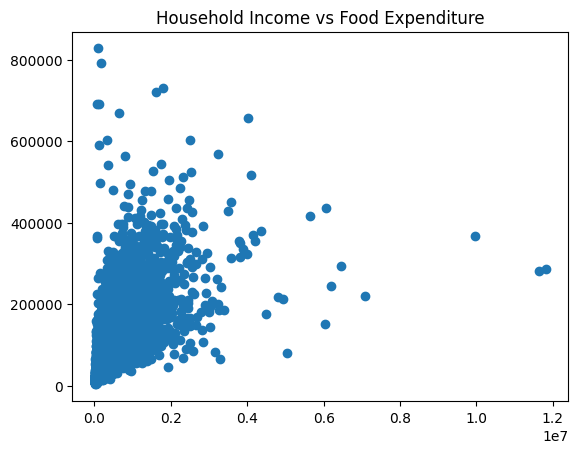

In [10]:
plt.figure()
plt.scatter(df['Total Household Income'], df['Total Food Expenditure'])
plt.title('Household Income vs Food Expenditure')
plt.show()

<h1>Insight:</h1><p>There is a visible upward trend: where households with higher income generaly spend more on food. However, the spread widensat higher income levels, showing that wealthier families vary more in how much they spend</p>

<Figure size 640x480 with 0 Axes>

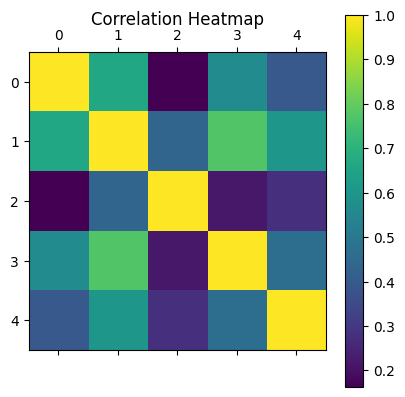

In [12]:
subset = df[['Total Household Income',
             'Total Food Expenditure', 
             'Total Rice Expenditure', 
             'Meat Expenditure', 
             'Total Fish and  marine products Expenditure']]
plt.figure()
plt.matshow(subset.corr())
plt.title('Correlation Heatmap', pad=20)
plt.colorbar()
plt.show()

In [17]:
from sklearn.linear_model import LinearRegression

In [25]:
df['Region'].value_counts()

Region
IVA - CALABARZON             4162
NCR                          4130
III - Central Luzon          3237
VI - Western Visayas         2851
VII - Central Visayas        2541
V - Bicol Region             2472
XI - Davao Region            2446
I - Ilocos Region            2348
VIII - Eastern Visayas       2337
 ARMM                        2248
II - Cagayan Valley          2219
XII - SOCCSKSARGEN           2122
X - Northern Mindanao        1887
IX - Zasmboanga Peninsula    1788
Caraga                       1782
CAR                          1725
IVB - MIMAROPA               1249
Name: count, dtype: int64

In [35]:
r2 = df[df['Region'] == 'II - Cagayan Valley']

X2 = r2[['Total Household Income']]
y2 = r2['Total Food Expenditure']

model = LinearRegression()
model.fit(X2, y2)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("Score:", model.score(X2, y2))

Coefficient: 0.09843838545593513
Intercept: 52296.292412099254
Score: 0.3565906125358784


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


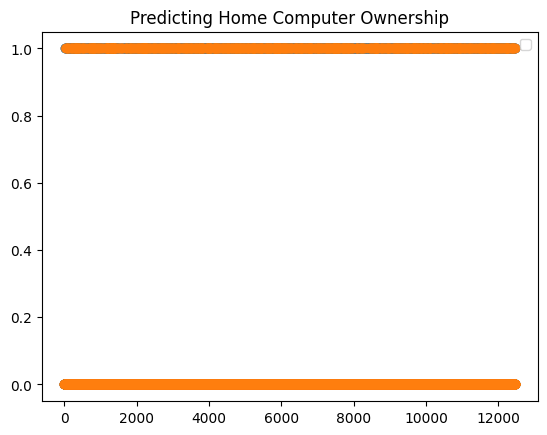

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

Xc = df[['Total Household Income', 'Education Expenditure']]
yc = (df['Number of Personal Computer'] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(Xc, yc, test_size=0.3)
clf = LogisticRegression(max_iter=300)
clf.fit(X_train, y_train)

pred = clf.predict(X_test)

plt.figure()
plt.scatter(range(len(y_test)), y_test, alpha=0.6)
plt.scatter(range(len(pred)), pred, alpha=0.6)
plt.title('Predicting Home Computer Ownership')
plt.legend()
plt.show()